# Medical Insurance Cost Prediction Using Machine Learning

This project predicts medical insurance premium costs using machine learning.

The dataset contains information such as age, diabetes, blood pressure problems, transplants, chronic diseases, height, weight, allergies, family history of cancer, and major surgeries.

In this project, I explore the dataset, preprocess the data, compare different regression models, tune the best-performing model, and evaluate the final model on unseen test data.

## Project Overview

**Goal:** Predict medical insurance premium costs using machine learning.

**Target Variable:** `PremiumPrice` — the medical insurance premium amount to be predicted.

**Dataset Size:** 986 rows × 11 columns

### Features and Their Meaning

| Column | Meaning |
|---|---|
| `Age` | Age of the person |
| `Diabetes` | Whether the person has diabetes (0 = No, 1 = Yes) |
| `BloodPressureProblems` | Whether the person has blood pressure problems |
| `AnyTransplants` | Whether the person has undergone a transplant |
| `AnyChronicDiseases` | Whether the person has any chronic disease |
| `Height` | Height of the person in cm |
| `Weight` | Weight of the person in kg |
| `KnownAllergies` | Whether the person has known allergies |
| `HistoryOfCancerInFamily` | Whether there is a history of cancer in the family |
| `NumberOfMajorSurgeries` | Number of major surgeries undergone |
| `PremiumPrice` | Medical insurance premium amount — **target variable** |

### Models Used

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor

### Tools and Libraries Used

- **Python**
- **NumPy** 
- **Pandas**
- **Matplotlib**
- **Seaborn**
- **Scikit-learn** 


## Importing Required Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [2]:
path='/kaggle/input/datasets/tejashvi14/medical-insurance-premium-prediction/Medicalpremium.csv'

In [3]:
df=pd.read_csv(path)

## Understanding the Dataset

In [4]:
df.shape

(986, 11)

In [5]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [6]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


## Checking Missing Values and Duplicates

In [8]:
df.isnull().sum()

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Data Visualization and Exploratory Data Analysis


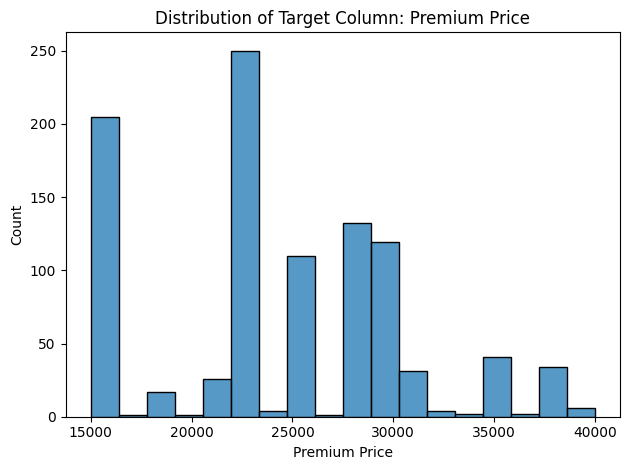

In [10]:
fig,ax=plt.subplots()
sns.histplot(x=df['PremiumPrice'],ax=ax)
ax.set_xlabel('Premium Price')
ax.set_title('Distribution of Target Column: Premium Price')
plt.tight_layout()
plt.show()

In [11]:
num_cols=df.columns.tolist()
num_cols.remove('PremiumPrice')
num_cols

['Age',
 'Diabetes',
 'BloodPressureProblems',
 'AnyTransplants',
 'AnyChronicDiseases',
 'Height',
 'Weight',
 'KnownAllergies',
 'HistoryOfCancerInFamily',
 'NumberOfMajorSurgeries']

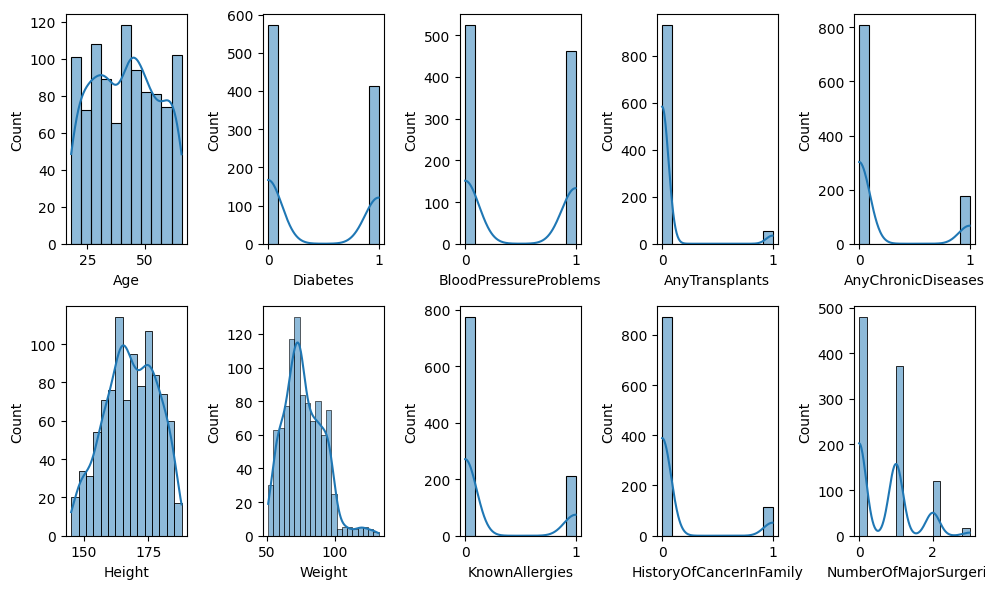

In [12]:
fig,ax=plt.subplots(2,5,figsize=(10,6))
ax=ax.flatten()
for i,column in enumerate(num_cols):
    sns.histplot(x=df[column],kde=True,ax=ax[i])
plt.tight_layout()
plt.show()
    

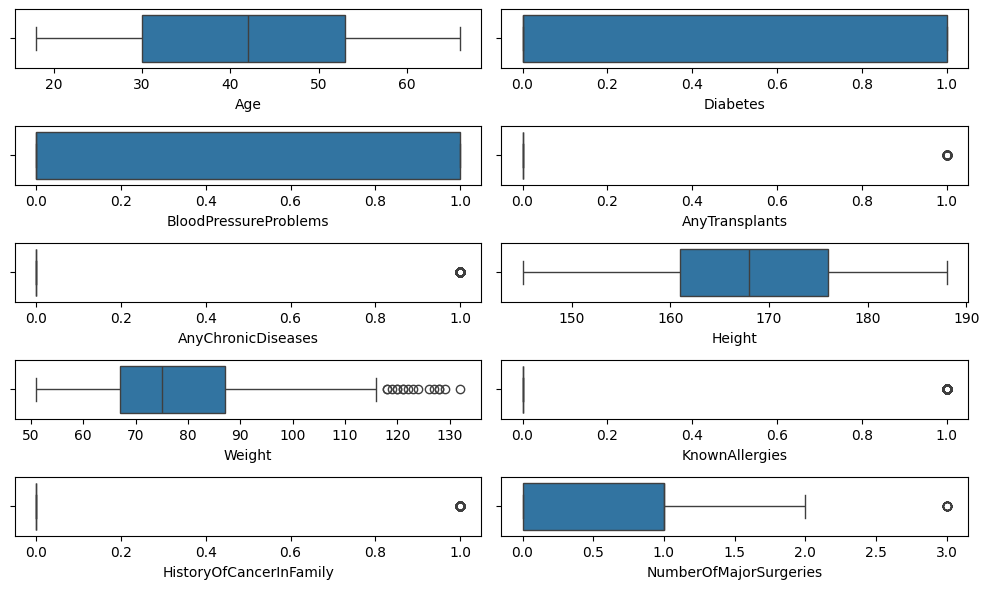

In [13]:
fig,ax=plt.subplots(5,2,figsize=(10,6))
ax=ax.flatten()
for i,column in enumerate(num_cols):
    sns.boxplot(x=df[column],vert=False,ax=ax[i])

plt.tight_layout()
plt.show()

<Axes: xlabel='AnyTransplants', ylabel='count'>

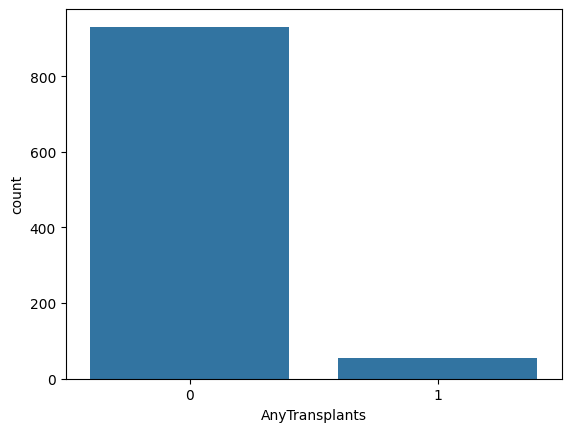

In [14]:
sns.barplot(df['AnyTransplants'].value_counts())

<Axes: xlabel='AnyChronicDiseases', ylabel='count'>

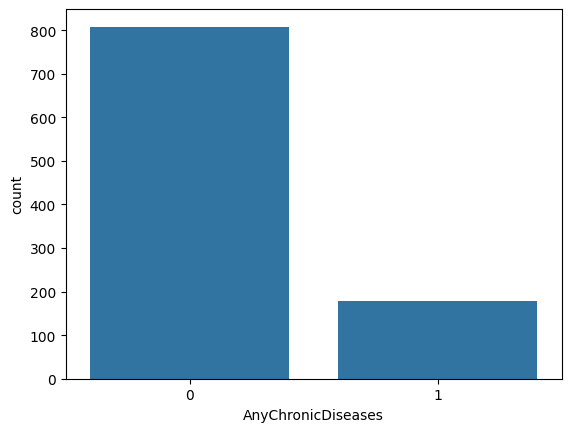

In [15]:
sns.barplot(df['AnyChronicDiseases'].value_counts())

<Axes: xlabel='KnownAllergies', ylabel='count'>

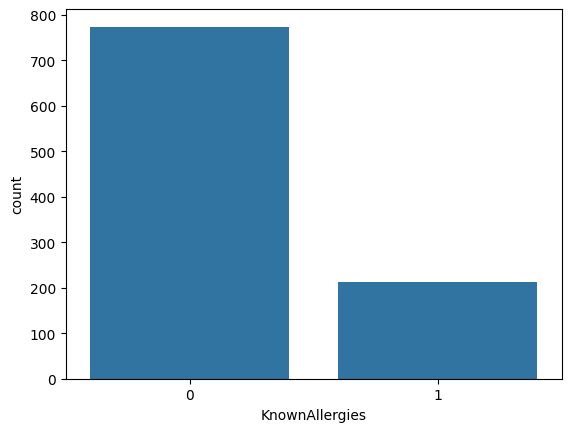

In [16]:
sns.barplot(df['KnownAllergies'].value_counts())

<Axes: xlabel='HistoryOfCancerInFamily', ylabel='count'>

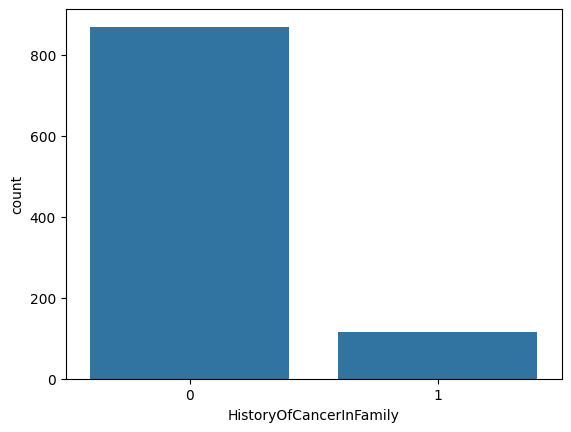

In [17]:
sns.barplot(df['HistoryOfCancerInFamily'].value_counts())

<Axes: >

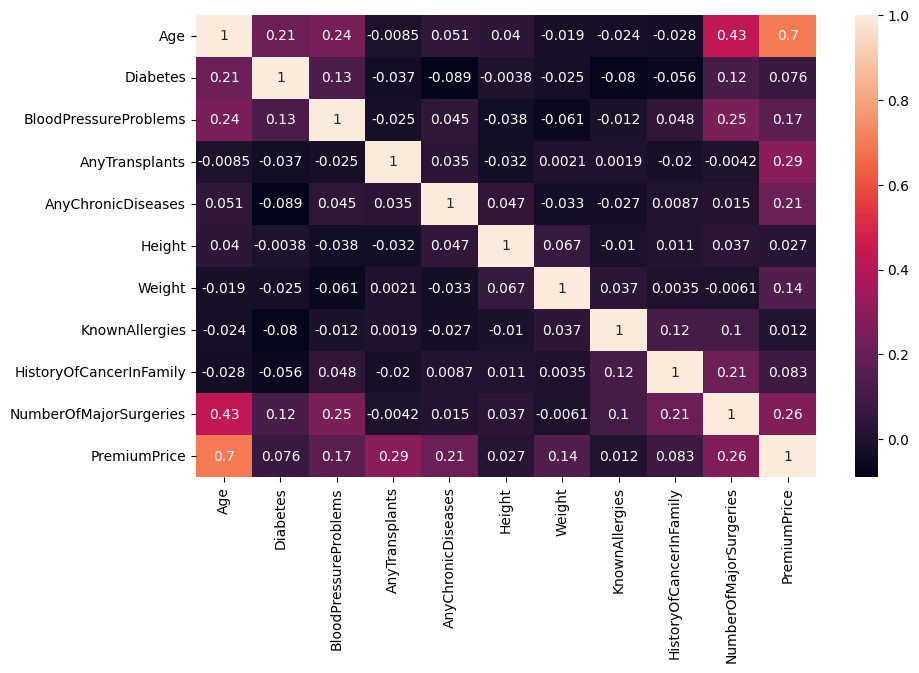

In [18]:
correlation_matrix=df.select_dtypes('number').corr()
fig,ax=plt.subplots(figsize=(10,6))
sns.heatmap(data=correlation_matrix,annot=True,ax=ax)

In [19]:
num_cols.append('PremiumPrice')

In [20]:
df[num_cols].corr()['PremiumPrice'].sort_values(ascending=False)

PremiumPrice               1.000000
Age                        0.697540
AnyTransplants             0.289056
NumberOfMajorSurgeries     0.264250
AnyChronicDiseases         0.208610
BloodPressureProblems      0.167097
Weight                     0.141507
HistoryOfCancerInFamily    0.083139
Diabetes                   0.076209
Height                     0.026910
KnownAllergies             0.012103
Name: PremiumPrice, dtype: float64

## Feature Correlation with Premium Price

The correlation values show that `Age` has the highest correlation with `PremiumPrice` among the input features in this dataset.

`AnyTransplants`, `NumberOfMajorSurgeries`, and `AnyChronicDiseases` also show positive correlations with the target.

## Preprocessing

In [21]:
from sklearn.model_selection import train_test_split

## Splitting the Data

In [22]:
X=df.drop('PremiumPrice',axis=1)
y=df['PremiumPrice']

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
print('Shape of traning data: ',X_train.shape)
print('Shape of testing data: ',X_test.shape)

Shape of traning data:  (788, 10)
Shape of testing data:  (198, 10)


The training set contains **788 rows**, while the testing set contains **198 rows**.

In [25]:
numerical_features=X_train.columns.tolist()
numerical_features

['Age',
 'Diabetes',
 'BloodPressureProblems',
 'AnyTransplants',
 'AnyChronicDiseases',
 'Height',
 'Weight',
 'KnownAllergies',
 'HistoryOfCancerInFamily',
 'NumberOfMajorSurgeries']

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.model_selection import KFold,cross_validate,GridSearchCV

## Creating the Preprocessing Pipeline

In [27]:
numerical_transforer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [28]:
preprocess=ColumnTransformer(
    transformers=[
    ('num',numerical_transforer,numerical_features)
    ]
)


## Creating a Baseline Model

In [29]:
baseline_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LinearRegression())
    ]
)

In [30]:
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Diabetes',
                                                   'BloodPressureProblems',
                                                   'AnyTransplants',
                                                   'AnyChronicDiseases',
                                                   'Height', 'Weight',
                                                   'KnownAllergies',
                                                   'HistoryOfCancerInFamily',
                                                   'NumberOfMajorSurgeries'])])),
                ('model', LinearRegression())])

In [31]:
baseline_predictions=baseline_model.predict(X_test)

In [32]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_squared_error,r2_score

## Baseline Model Evaluation

In [33]:
print('RMSE:',root_mean_squared_error(y_test,baseline_predictions))
print('MAE:',mean_absolute_error(y_test,baseline_predictions))
print('MSE:',mean_squared_error(y_test,baseline_predictions))
print('r2_score:',r2_score(y_test,baseline_predictions))


RMSE: 3495.949328273825
MAE: 2586.2253840681074
MSE: 12221661.705858208
r2_score: 0.713394427027874


### Baseline Results

The Linear Regression baseline achieved an R² score of approximately **0.713**, meaning that the model explains about **71.34% of the variation in the test data**.

These results provide a reference point for comparing the other regression models.

## Comparing Multiple Regression Models

In [34]:
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(random_state=42),
    'Lasso':Lasso(random_state=42,max_iter=10000),
    'RandomForest':RandomForestRegressor(),
    'GD':GradientBoostingRegressor()
}

## 5-Fold Cross-Validation

In [35]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=42)

## Evaluation Metrics

For model comparison, I used three metrics:

- **RMSE:** Lower values indicate smaller prediction errors.
- **MAE:** Lower values indicate smaller average absolute errors.
- **R²:** Higher values indicate that the model explains more variation in the target.

In [36]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [37]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("cv_rmse")

print("=== Model Comparison ===")
print(cv_results)

=== Model Comparison ===
              model      cv_rmse       cv_mae     cv_r2
3      RandomForest  2959.533612  1254.549141  0.756064
4                GD  3069.878672  1699.941674  0.740777
2             Lasso  3846.220717  2746.255586  0.603087
1             Ridge  3846.400296  2747.026943  0.603072
0  LinearRegression  3846.431247  2746.417877  0.603034


## Cross-Validation Results

The cross-validation results show that Random Forest achieved the lowest RMSE among the tested models.

Random Forest also achieved the lowest MAE and the highest R² score in this comparison.

Based on these cross-validation results, I selected Random Forest for further hyperparameter tuning.

## Random Forest Hyperparameter Tuning

In [38]:
rf_pipe=Pipeline(
    steps=[
    ('preprocess',preprocess),
    ('model',RandomForestRegressor(random_state=42))
    ]
)

In [39]:
param_grid={
     "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 1.0]
}

## GridSearchCV

In [40]:
rf_grid=GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)

In [41]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Diabetes',
                                                                          'BloodPressureProblems',
                                                                          'AnyTransplants',
                                                                          'AnyChronicDiseases',
                                                                          'Height',
                                                                          'Weight',
                                                                          'KnownAllergies',
                                                                          'HistoryOfCancerInFamily',
                                                                          'NumberOfMajorSurgeries'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 1.0],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [42]:
print("=== TUNED RANDOM FOREST ===")
print("Best CV RMSE:", -rf_grid.best_score_)
print("Best Parameters:")
print(rf_grid.best_params_)

=== TUNED RANDOM FOREST ===
Best CV RMSE: 2910.4019764063883
Best Parameters:
{'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}


## Best Random Forest Parameters

The grid search found the following parameter combination:

- `n_estimators = 300`
- `max_depth = None`
- `max_features = 1.0`
- `min_samples_leaf = 2`
- `min_samples_split = 5`

The best cross-validation RMSE was approximately **2910.40**.

## Retraining the Final Random Forest Model

In [43]:
final_model_rf=Pipeline(
steps=[
('preprocess',preprocess),
('model',RandomForestRegressor(max_depth=None,max_features=1.0,min_samples_leaf=2,min_samples_split=5, n_estimators =300,random_state=42
))
])

## Training the Final Model

In [44]:
final_model_rf.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Diabetes',
                                                   'BloodPressureProblems',
                                                   'AnyTransplants',
                                                   'AnyChronicDiseases',
                                                   'Height', 'Weight',
                                                   'KnownAllergies',
                                                   'HistoryOfCancerInFamily',
                                                   'NumberOfMajorSurgeries'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=300, random_state=42))])

## Making Predictions on the Test Data

In [45]:
rf_predictions=final_model_rf.predict(X_test)

## Final Model Evaluation

In [46]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=== TUNED RANDOM FOREST TEST RESULTS ===")
print("RMSE:", root_mean_squared_error(y_test, rf_predictions))
print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("MSE:", mean_squared_error(y_test, rf_predictions))
print("R² Score:", r2_score(y_test, rf_predictions))

=== TUNED RANDOM FOREST TEST RESULTS ===
RMSE: 2052.8378811300704
MAE: 955.8236631961381
MSE: 4214143.366202597
R² Score: 0.9011757154529776


## Final Results

The tuned Random Forest model achieved the following results on the unseen test data:

- **RMSE:** 2052.84
- **MAE:** 955.82
- **MSE:** 4,214,143.37
- **R² Score:** 0.9012

The R² score of approximately **0.9012 means that the final model explains about 90.12% of the variation in the test data**.

The final model was evaluated on the test set after the hyperparameter tuning process was completed.

## Conclusion

In this project, I built a machine learning model to predict medical insurance premium costs.

The main steps followed were:

1. Loaded and explored the dataset.
2. Checked the data for missing values and duplicates.
3. Performed exploratory data analysis and visualization.
4. Split the data into training and testing sets.
5. Created a preprocessing pipeline.
6. Built Linear Regression as a baseline model.
7. Compared multiple regression models using 5-fold cross-validation.
8. Selected Random Forest for further tuning based on the cross-validation results.
9. Used GridSearchCV to find better Random Forest hyperparameters.
10. Retrained the final Random Forest model using the selected parameters.
11. Evaluated the final model on unseen test data.

The final tuned Random Forest achieved an **R² score of approximately 90.12%** on the test dataset.

This project helped me practice the complete machine learning workflow, from data exploration and preprocessing to model comparison, hyperparameter tuning, and final evaluation.